<a href="https://colab.research.google.com/github/stanokoye/nigeria-weather-risk-analysis/blob/main/notebooks/02_exploratory_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Libraries loaded successfully')


Libraries loaded successfully


In [8]:
# Load the cleaned datasets
df = pd.read_csv('abagana_climate_daily_2020_2025.csv',
                  index_col='date', parse_dates=True)

jja = pd.read_csv('abagana_jja_2020_2025.csv',
                   index_col='date', parse_dates=True)

monthly_summary = pd.read_csv('abagana_monthly_summary.csv',
                               index_col='month_name')

print(f'Full dataset: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'JJA dataset: {jja.shape[0]} rows, {jja.shape[1]} columns')
print(f'Date range: {df.index.min()} to {df.index.max()}')


Full dataset: 2192 rows, 11 columns
JJA dataset: 552 rows, 11 columns
Date range: 2020-01-01 00:00:00 to 2025-12-31 00:00:00


In [9]:
import os

# Search for the CSV files
for root, dirs, files_list in os.walk('/'):
    for file in files_list:
        if 'abagana' in file:
            print(os.path.join(root, file))


/content/abagana_monthly_summary.csv
/content/abagana_climate_daily_2020_2025.csv
/content/abagana_jja_2020_2025.csv


In [10]:
# Load the cleaned datasets
df = pd.read_csv('abagana_climate_daily_2020_2025.csv',
                  index_col='date', parse_dates=True)

jja = pd.read_csv('abagana_jja_2020_2025.csv',
                   index_col='date', parse_dates=True)

monthly_summary = pd.read_csv('abagana_monthly_summary.csv',
                               index_col='month_name')

print(f'Full dataset: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'JJA dataset: {jja.shape[0]} rows, {jja.shape[1]} columns')
print(f'Date range: {df.index.min()} to {df.index.max()}')

Full dataset: 2192 rows, 11 columns
JJA dataset: 552 rows, 11 columns
Date range: 2020-01-01 00:00:00 to 2025-12-31 00:00:00


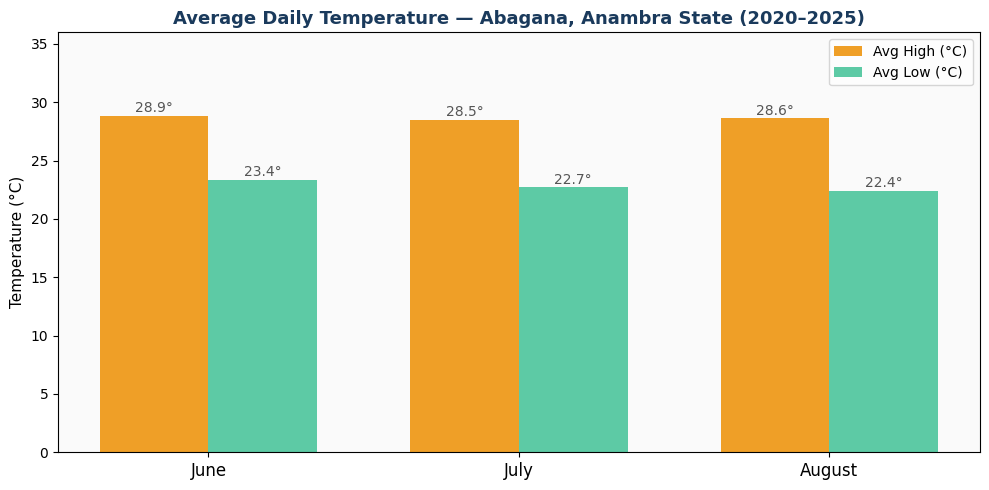

Chart saved


In [11]:
# Chart 1 — Monthly average temperature (June, July, August)
fig, ax = plt.subplots(figsize=(10, 5))

months = ['June', 'July', 'August']
temp_max = [monthly_summary.loc[m, 'avg_temp_max'] for m in months]
temp_min = [monthly_summary.loc[m, 'avg_temp_min'] for m in months]

x = np.arange(len(months))
width = 0.35

bars1 = ax.bar(x - width/2, temp_max, width, label='Avg High (°C)', color='#EF9F27', edgecolor='none')
bars2 = ax.bar(x + width/2, temp_min, width, label='Avg Low (°C)', color='#5DCAA5', edgecolor='none')

ax.set_xticks(x)
ax.set_xticklabels(months, fontsize=12)
ax.set_ylabel('Temperature (°C)', fontsize=11)
ax.set_title('Average Daily Temperature — Abagana, Anambra State (2020–2025)', fontsize=13, fontweight='bold', color='#1A3A5C')
ax.set_ylim(0, 36)
ax.legend(fontsize=10)
ax.set_facecolor('#FAFAFA')

for b in bars1:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{b.get_height():.1f}°', ha='center', fontsize=10, color='#555')
for b in bars2:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{b.get_height():.1f}°', ha='center', fontsize=10, color='#555')

plt.tight_layout()
plt.savefig('chart_temperature.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Chart saved')

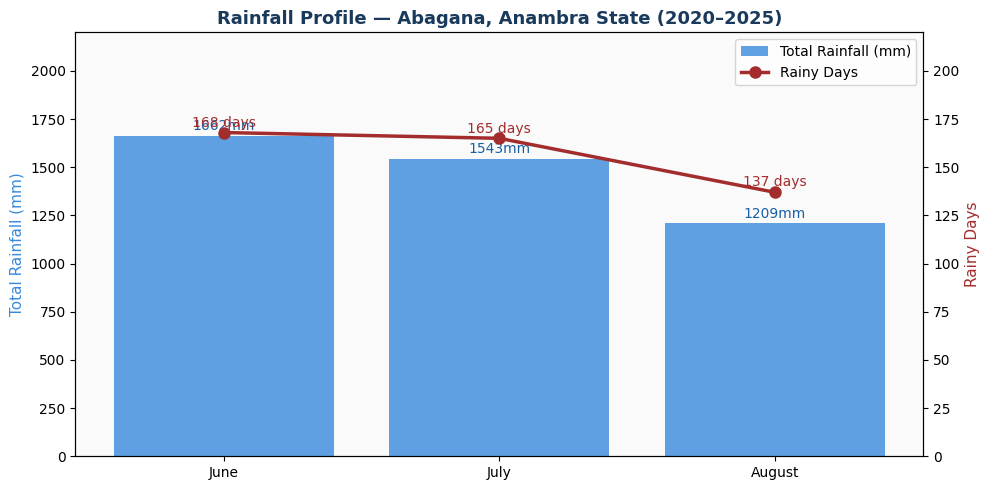

Chart saved


In [13]:
# Chart 2 — Monthly rainfall and rainy days (June, July, August)
fig, ax1 = plt.subplots(figsize=(10, 5))

months = ['June', 'July', 'August']
rainfall = [monthly_summary.loc[m, 'total_rainfall'] for m in months]
rainy_days = [monthly_summary.loc[m, 'rainy_days'] for m in months]

ax2 = ax1.twinx()

bars = ax1.bar(months, rainfall, color='#378ADD', edgecolor='none', alpha=0.8, label='Total Rainfall (mm)')
line = ax2.plot(months, rainy_days, 'o-', color='#A32D2D', linewidth=2.5, markersize=8, label='Rainy Days')

ax1.set_ylabel('Total Rainfall (mm)', fontsize=11, color='#378ADD')
ax2.set_ylabel('Rainy Days', fontsize=11, color='#A32D2D')
ax1.set_title('Rainfall Profile — Abagana, Anambra State (2020–2025)', fontsize=13, fontweight='bold', color='#1A3A5C')
ax1.set_ylim(0, 2200)
ax2.set_ylim(0, 220)
ax1.set_facecolor('#FAFAFA')

for i, (mm, rd) in enumerate(zip(rainfall, rainy_days)):
    ax1.text(i, mm + 30, f'{mm:.0f}mm', ha='center', fontsize=10, color='#185FA5')
    ax2.text(i, rd + 3, f'{rd:.0f} days', ha='center', fontsize=10, color='#A32D2D')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('chart_rainfall.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Chart saved')

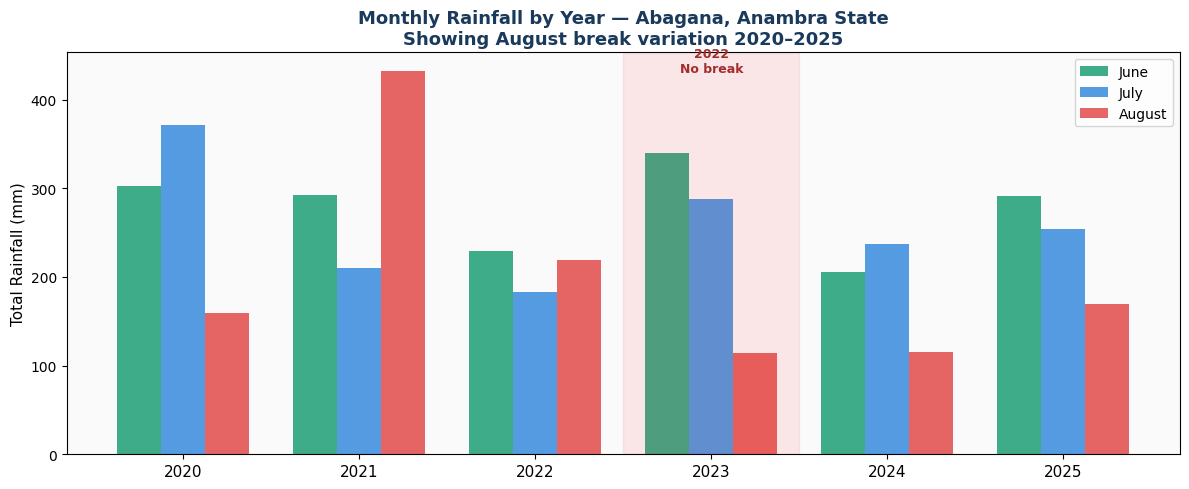

Chart saved


In [14]:
# Chart 3 — Rainfall by month and year (shows August break variation)
fig, ax = plt.subplots(figsize=(12, 5))

yearly_monthly = jja.groupby(['year', 'month_name'])['rainfall_mm'].sum().reset_index()

years = sorted(jja['year'].unique())
months = ['June', 'July', 'August']
colors = ['#1D9E75', '#378ADD', '#E24B4A']
x = np.arange(len(years))
width = 0.25

for i, (month, color) in enumerate(zip(months, colors)):
    data = yearly_monthly[yearly_monthly['month_name'] == month]
    bars = ax.bar(x + i * width, data['rainfall_mm'], width,
                  label=month, color=color, edgecolor='none', alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(years, fontsize=11)
ax.set_ylabel('Total Rainfall (mm)', fontsize=11)
ax.set_title('Monthly Rainfall by Year — Abagana, Anambra State\nShowing August break variation 2020–2025',
             fontsize=13, fontweight='bold', color='#1A3A5C')
ax.legend(fontsize=10)
ax.set_facecolor('#FAFAFA')

# Highlight 2022 — the year with no August break
ax.axvspan(2.75, 3.75, alpha=0.08, color='red')
ax.text(3.25, ax.get_ylim()[1] * 0.95, '2022\nNo break',
        ha='center', fontsize=9, color='#A32D2D', fontweight='bold')

plt.tight_layout()
plt.savefig('chart_yearly_rainfall.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Chart saved')

In [15]:
# Chart 4 — Weekend Risk Scoring Model
# Define all 10 Thu-Sun weekends in the research period

weekends = [
    {'weekend': 'Jun 18–21', 'start': '2026-06-18', 'end': '2026-06-21', 'month': 6},
    {'weekend': 'Jun 25–28', 'start': '2026-06-25', 'end': '2026-06-28', 'month': 6},
    {'weekend': 'Jul 2–5',   'start': '2026-07-02', 'end': '2026-07-05', 'month': 7},
    {'weekend': 'Jul 9–12',  'start': '2026-07-09', 'end': '2026-07-12', 'month': 7},
    {'weekend': 'Jul 16–19', 'start': '2026-07-16', 'end': '2026-07-19', 'month': 7},
    {'weekend': 'Jul 23–26', 'start': '2026-07-23', 'end': '2026-07-26', 'month': 7},
    {'weekend': 'Jul 30–Aug 2', 'start': '2026-07-30', 'end': '2026-08-02', 'month': 8},
    {'weekend': 'Aug 6–9',   'start': '2026-08-06', 'end': '2026-08-09', 'month': 8},
    {'weekend': 'Aug 13–16', 'start': '2026-08-13', 'end': '2026-08-16', 'month': 8},
    {'weekend': 'Aug 20–23', 'start': '2026-08-20', 'end': '2026-08-23', 'month': 8},
]

# Monthly base risk scores derived from NASA data
# Based on: rainy days per month, total rainfall, rain type
monthly_base = {6: 52, 7: 68, 8: 55}

# August break adjustment (weeks 4-5 of July, week 1 of August)
aug_break_weekends = ['Jul 23–26', 'Jul 30–Aug 2']
aug_break_adjustment = -8  # Moderate reduction — unreliable in Anambra

# Week progression adjustment — risk increases as month deepens
week_adjustment = {
    'Jun 18–21': -3,  # Early in month — lower
    'Jun 25–28':  2,  # Late June — slight increase
    'Jul 2–5':    2,
    'Jul 9–12':   4,
    'Jul 16–19':  6,  # Peak July
    'Jul 23–26':  0,
    'Jul 30–Aug 2': 0,
    'Aug 6–9':   12,  # Peak August
    'Aug 13–16': 14,
    'Aug 20–23': 11,
}

# Calculate final risk score for each weekend
for w in weekends:
    base = monthly_base[w['month']]
    week_adj = week_adjustment[w['weekend']]
    break_adj = aug_break_adjustment if w['weekend'] in aug_break_weekends else 0
    w['risk_score'] = base + week_adj + break_adj

df_weekends = pd.DataFrame(weekends)
print(df_weekends[['weekend', 'risk_score']])

        weekend  risk_score
0     Jun 18–21          49
1     Jun 25–28          54
2       Jul 2–5          70
3      Jul 9–12          72
4     Jul 16–19          74
5     Jul 23–26          60
6  Jul 30–Aug 2          47
7       Aug 6–9          67
8     Aug 13–16          69
9     Aug 20–23          66


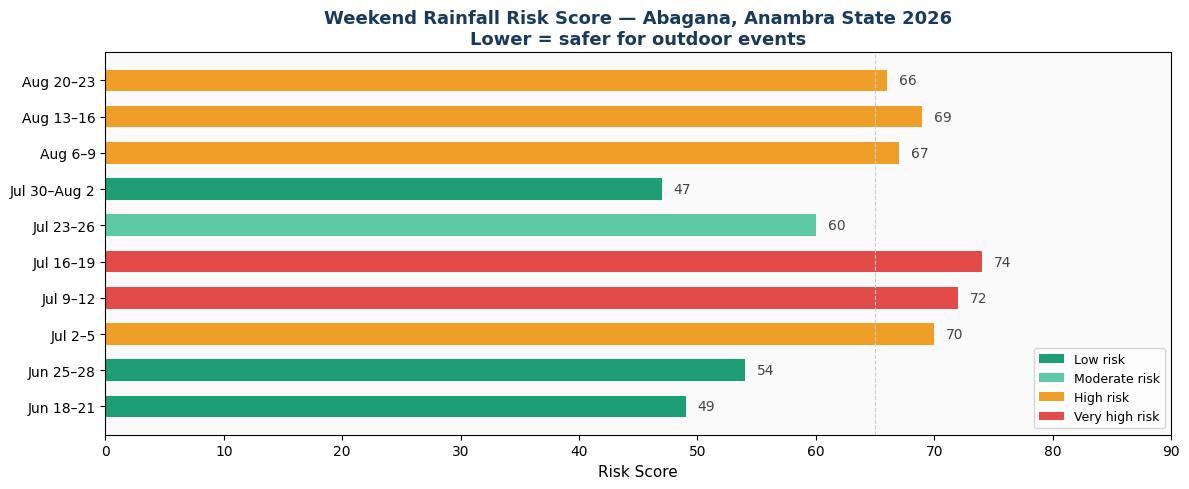

Chart saved


In [16]:
# Chart 4 — Weekend Risk Score Visualisation
colors = []
for score in df_weekends['risk_score']:
    if score < 55:
        colors.append('#1D9E75')
    elif score < 65:
        colors.append('#5DCAA5')
    elif score < 72:
        colors.append('#EF9F27')
    else:
        colors.append('#E24B4A')

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(df_weekends['weekend'], df_weekends['risk_score'],
               color=colors, edgecolor='none', height=0.6)

ax.set_xlim(0, 90)
ax.set_xlabel('Risk Score', fontsize=11)
ax.set_title('Weekend Rainfall Risk Score — Abagana, Anambra State 2026\nLower = safer for outdoor events',
             fontsize=13, fontweight='bold', color='#1A3A5C')
ax.set_facecolor('#FAFAFA')
ax.axvline(x=65, color='#ccc', linestyle='--', linewidth=0.8)

for bar, score in zip(bars, df_weekends['risk_score']):
    ax.text(score + 1, bar.get_y() + bar.get_height()/2,
            str(score), va='center', fontsize=10, color='#444')

import matplotlib.patches as mpatches
legend = [
    mpatches.Patch(facecolor='#1D9E75', label='Low risk'),
    mpatches.Patch(facecolor='#5DCAA5', label='Moderate risk'),
    mpatches.Patch(facecolor='#EF9F27', label='High risk'),
    mpatches.Patch(facecolor='#E24B4A', label='Very high risk'),
]
ax.legend(handles=legend, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('chart_risk_scores.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Chart saved')

In [17]:
# Key Findings Summary
print("=" * 60)
print("KEY ANALYTICAL FINDINGS")
print("=" * 60)

print("\n1. RISK SCORES (lowest to highest):")
print(df_weekends[['weekend', 'risk_score']]
      .sort_values('risk_score')
      .to_string(index=False))

print("\n2. PRIMARY RECOMMENDATION:")
best = df_weekends.loc[df_weekends['risk_score'].idxmin()]
print(f"   {best['weekend']} — Risk score: {best['risk_score']}")

print("\n3. KEY DATA INSIGHT:")
print("""
   NASA data (2020-2025) reveals that June has HIGHER total
   rainfall than August (1,661mm vs 1,209mm), but August has
   FEWER rainy days (137 vs 168). This means:

   - June rain = frequent, short convective storms (manageable)
   - August rain = less frequent but persistent, all-day events
     with significantly higher flood risk

   Total rainfall alone is NOT a reliable risk indicator for
   event planning. Rain TYPE and TIMING matter more.
""")

print("4. AUGUST BREAK FINDING:")
print("""
   Jul 30–Aug 2 scores 47 — lowest in the period.
   However, peer-reviewed research confirms the August break
   is weakening in southeastern Nigeria. This score reflects
   historical averages, not guaranteed 2026 conditions.
   Treat as opportunity, not certainty.
""")

KEY ANALYTICAL FINDINGS

1. RISK SCORES (lowest to highest):
     weekend  risk_score
Jul 30–Aug 2          47
   Jun 18–21          49
   Jun 25–28          54
   Jul 23–26          60
   Aug 20–23          66
     Aug 6–9          67
   Aug 13–16          69
     Jul 2–5          70
    Jul 9–12          72
   Jul 16–19          74

2. PRIMARY RECOMMENDATION:
   Jul 30–Aug 2 — Risk score: 47

3. KEY DATA INSIGHT:

   NASA data (2020-2025) reveals that June has HIGHER total 
   rainfall than August (1,661mm vs 1,209mm), but August has 
   FEWER rainy days (137 vs 168). This means:
   
   - June rain = frequent, short convective storms (manageable)
   - August rain = less frequent but persistent, all-day events
     with significantly higher flood risk
     
   Total rainfall alone is NOT a reliable risk indicator for 
   event planning. Rain TYPE and TIMING matter more.

4. AUGUST BREAK FINDING:

   Jul 30–Aug 2 scores 47 — lowest in the period.
   However, peer-reviewed research conf

In [18]:
# Export weekend risk scores for Power BI
df_weekends['rating'] = df_weekends['risk_score'].apply(
    lambda x: 'Best' if x < 55 else ('Moderate' if x < 65 else ('High Risk' if x < 72 else 'Avoid'))
)

df_weekends['recommendation'] = df_weekends['weekend'].map({
    'Jun 18–21':     'Primary recommendation',
    'Jun 25–28':     'Secondary recommendation',
    'Jul 2–5':       'Risky — avoid if possible',
    'Jul 9–12':      'Risky — avoid if possible',
    'Jul 16–19':     'Risky — avoid if possible',
    'Jul 23–26':     'August break — not guaranteed',
    'Jul 30–Aug 2':  'August break — contingency only',
    'Aug 6–9':       'Avoid',
    'Aug 13–16':     'Avoid',
    'Aug 20–23':     'Avoid',
})

df_weekends.to_csv('weekend_risk_scores.csv', index=False)
print('Weekend risk scores exported')
print(df_weekends[['weekend', 'risk_score', 'rating', 'recommendation']])

Weekend risk scores exported
        weekend  risk_score     rating                   recommendation
0     Jun 18–21          49       Best           Primary recommendation
1     Jun 25–28          54       Best         Secondary recommendation
2       Jul 2–5          70  High Risk        Risky — avoid if possible
3      Jul 9–12          72      Avoid        Risky — avoid if possible
4     Jul 16–19          74      Avoid        Risky — avoid if possible
5     Jul 23–26          60   Moderate    August break — not guaranteed
6  Jul 30–Aug 2          47       Best  August break — contingency only
7       Aug 6–9          67  High Risk                            Avoid
8     Aug 13–16          69  High Risk                            Avoid
9     Aug 20–23          66  High Risk                            Avoid


In [19]:
from google.colab import files

files.download('chart_temperature.png')
files.download('chart_rainfall.png')
files.download('chart_yearly_rainfall.png')
files.download('chart_risk_scores.png')
files.download('weekend_risk_scores.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>